In [3]:
import numpy as np
import cv2 as cv
import open3d as o3d
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import urllib.request
import os

In [ ]:
base_url = "https://raw.githubusercontent.com/Delevati/vc-2024-2/main/img/task04/q2"
kitti_scenes = ["000010", "000032", "000188"]

image_urls = {}
for scene_id in kitti_scenes:
    image_urls[scene_id] = {
        'left': f"{base_url}/{scene_id}_10.png",
        'right': f"{base_url}/{scene_id}_11.png",
        'calib': f"{base_url}/{scene_id}.txt"
    }

def read_kitti_calib_file(calib_path):
    try:
        with open(calib_path, 'r') as f:
            lines = f.readlines()
            
        calib_data = {}
        for line in lines:
            line = line.strip()
            if not line or line.startswith('//'):
                continue
                
            key_value = line.split(':', 1)
            if len(key_value) != 2:
                continue
                
            key, value = key_value
            key = key.strip()
            
            if key in ['calib_time']:
                continue
                
            try:
                values = [float(x) for x in value.strip().split()]
                
                if key in ['P_rect_00', 'P_rect_01', 'P_rect_02', 'P_rect_03']:
                    values = np.array(values).reshape(3, 4)
                elif key in ['R_rect_00', 'R_rect_01', 'R_rect_02', 'R_rect_03']:
                    values = np.array(values).reshape(3, 3)
                elif key in ['K_00', 'K_01', 'K_02', 'K_03']:
                    values = np.array(values).reshape(3, 3)
                else:
                    values = np.array(values)
                    
                calib_data[key] = values
            except ValueError:
                pass
                
        return {
            'P2': calib_data['P_rect_02'],
            'P3': calib_data['P_rect_03']
        }
        
    except Exception:
        return None

In [ ]:
def write_ply(filename, verts, colors):
    verts = verts.reshape(-1, 3)
    colors = colors.reshape(-1, 3)
    verts = np.hstack([verts, colors])
    ply_header = '''ply
format ascii 1.0
element vertex %(vert_num)d
property float x
property float y
property float z
property uchar red
property uchar green
property uchar blue
end_header
'''
    with open(filename, 'w') as f:
        f.write(ply_header % dict(vert_num=len(verts)))
        np.savetxt(f, verts, '%f %f %f %d %d %d')

results = []

for scene_id in kitti_scenes:
    try:
        left_img = cv.imread(f"/Users/luryand/Documents/VC/img/task04/q2/{scene_id}_10.png")
        right_img = cv.imread(f"/Users/luryand/Documents/VC/img/task04/q2/{scene_id}_11.png")
            
        left_gray = cv.cvtColor(left_img, cv.COLOR_BGR2GRAY)
        right_gray = cv.cvtColor(right_img, cv.COLOR_BGR2GRAY)
        
        calib_data = read_kitti_calib_file(f"/Users/luryand/Documents/VC/img/task04/q2/{scene_id}.txt")
            
        if calib_data is None:
            h, w = left_gray.shape
            focal_length = max(h, w)
            cx, cy = w/2, h/2
            P2 = np.array([
                [focal_length, 0, cx, 0],
                [0, focal_length, cy, 0],
                [0, 0, 1, 0]
            ])
            P3 = P2.copy()
            P3[0, 3] = -0.54 * focal_length
            calib_data = {'P2': P2, 'P3': P3}
        
        stereo = cv.StereoSGBM_create(
            numDisparities=128,
            blockSize=5,
            P1=8*3*7**2,
            P2=32*3*7**2,
            disp12MaxDiff=1,
            uniquenessRatio=15,
            speckleWindowSize=100,
            speckleRange=32,
            preFilterCap=63,
            minDisparity=0
        )
        disparity = stereo.compute(left_gray, right_gray).astype(np.float32) / 16.0
        
        disp_norm = cv.normalize(disparity, None, 0, 255, norm_type=cv.NORM_MINMAX, dtype=cv.CV_8U)
        disp_blur = cv.medianBlur(disp_norm, 5)
        
        cam1 = calib_data['P2'][:, :3]
        cam2 = calib_data['P3'][:, :3]
        
        T_x = (calib_data['P3'][0, 3] - calib_data['P2'][0, 3]) / calib_data['P3'][0, 0]
        T = np.array([T_x, 0., 0.])
        
        h, w = left_gray.shape
        Q = np.zeros((4, 4))
        cv.stereoRectify(
            cameraMatrix1=cam1, cameraMatrix2=cam2,
            distCoeffs1=None, distCoeffs2=None,
            imageSize=(w, h),
            R=np.identity(3), T=T,
            R1=None, R2=None, P1=None, P2=None, Q=Q,
            flags=cv.CALIB_ZERO_DISPARITY, alpha=0
        )
        
        points_3D = cv.reprojectImageTo3D(disparity, Q)
        colors = cv.cvtColor(left_img, cv.COLOR_BGR2RGB)
        
        mask = (disparity > 0) & (disparity < 128) & np.isfinite(points_3D[:,:,2])
        out_points = points_3D[mask]
        out_colors = colors[mask]
        
        ply_filename = f"{scene_id}_pointcloud.ply"
        write_ply(ply_filename, out_points, out_colors)
        
        results.append({
            'scene_id': scene_id,
            'left_img': left_img,
            'right_img': right_img,
            'disparity': disparity,
            'disp_norm': disp_norm,
            'disp_blur': disp_blur,
            'points_3D': points_3D,
            'out_points': out_points,
            'out_colors': out_colors,
            'Q': Q,
            'ply_filename': ply_filename
        })
    except Exception:
        continue

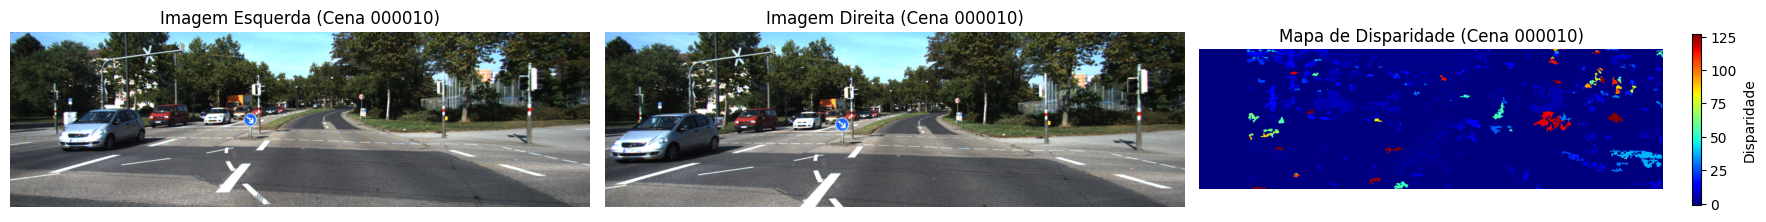

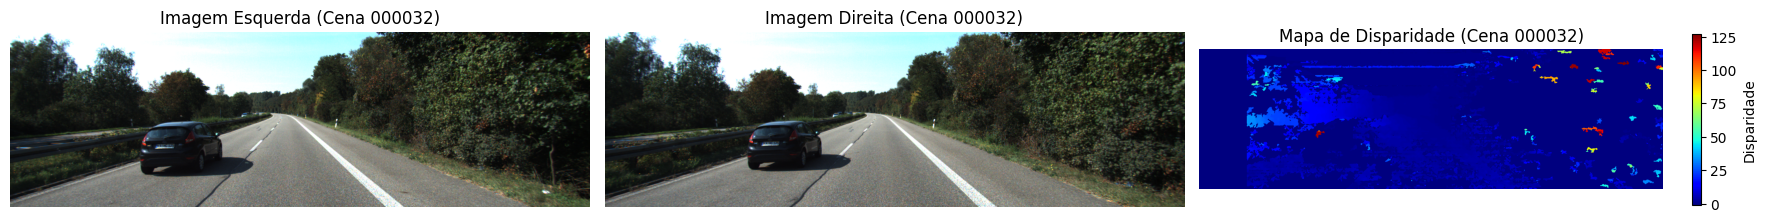

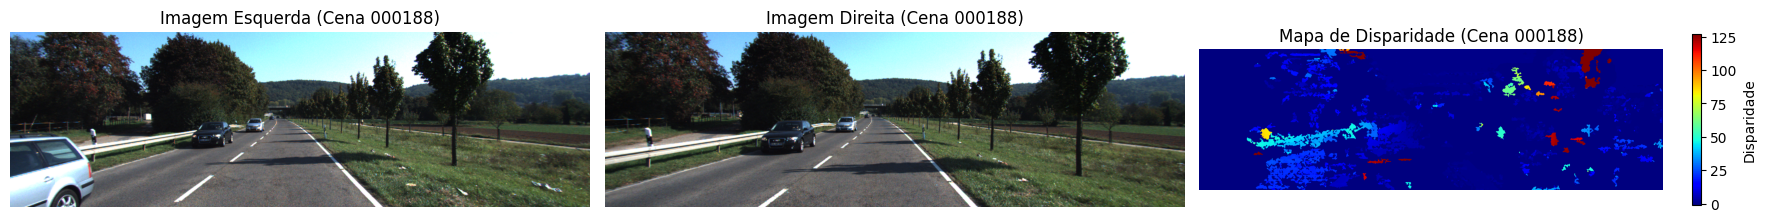

In [23]:
for result in results:
    scene_id = result['scene_id']
    
    plt.figure(figsize=(18, 6))
    
    plt.subplot(131)
    plt.imshow(cv.cvtColor(result['left_img'], cv.COLOR_BGR2RGB))
    plt.title(f"Imagem Esquerda (Cena {scene_id})")
    plt.axis('off')
    
    plt.subplot(132)
    plt.imshow(cv.cvtColor(result['right_img'], cv.COLOR_BGR2RGB))
    plt.title(f"Imagem Direita (Cena {scene_id})")
    plt.axis('off')
    
    plt.subplot(133)
    plt.imshow(result['disparity'], cmap='jet')
    plt.colorbar(shrink=0.3, label='Disparidade')
    plt.title(f"Mapa de Disparidade (Cena {scene_id})")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

In [24]:
for result in results:
    scene_id = result['scene_id']
    
    idx = np.random.choice(len(result['out_points']), 
                          size=min(30000, len(result['out_points'])), 
                          replace=False)
    pts = result['out_points'][idx]
    cols = result['out_colors'][idx] / 255.0
    
    fig = go.Figure(data=[go.Scatter3d(
        x=pts[:, 0], y=pts[:, 1], z=pts[:, 2],
        mode='markers',
        marker=dict(
            size=2,
            color=cols,
            opacity=0.8
        ),
        name='Nuvem de Pontos'
    )])
    
    fig.update_layout(
        title={
            'text': f"Nuvem de Pontos 3D - Cena KITTI {scene_id}",
            'y': 0.95,
            'x': 0.5,
            'xanchor': 'center',
            'yanchor': 'top'
        },
        scene=dict(
            xaxis_title='Eixo X',
            yaxis_title='Eixo Y',
            zaxis_title='Eixo Z',
            xaxis=dict(showbackground=True, backgroundcolor="rgb(230, 230, 230)", gridcolor='white'),
            yaxis=dict(showbackground=True, backgroundcolor="rgb(230, 230, 230)", gridcolor='white'),
            zaxis=dict(showbackground=True, backgroundcolor="rgb(230, 230, 230)", gridcolor='white'),
            camera=dict(
                up=dict(x=0, y=0, z=1),
                eye=dict(x=1.5, y=1.5, z=1.2)
            ),
            aspectmode='data'
        ),
        margin=dict(l=0, r=0, b=0, t=0),
        legend=dict(
            yanchor="top",
            y=0.99,
            xanchor="left",
            x=0.01
        )
    )
    
    fig.show()

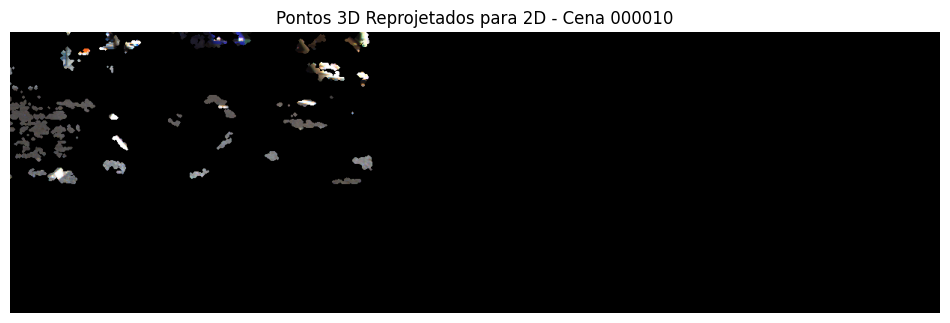

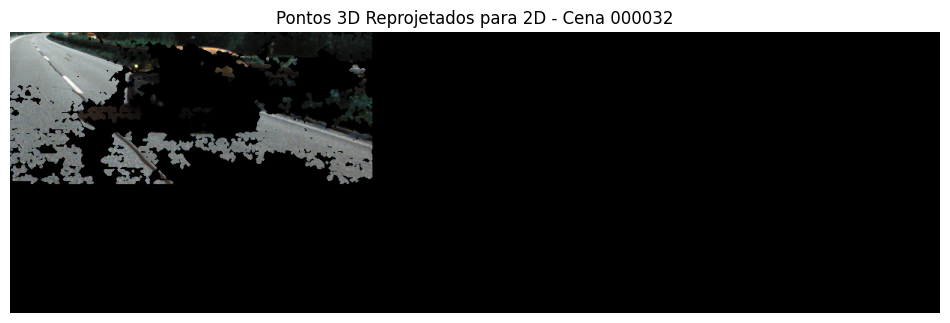

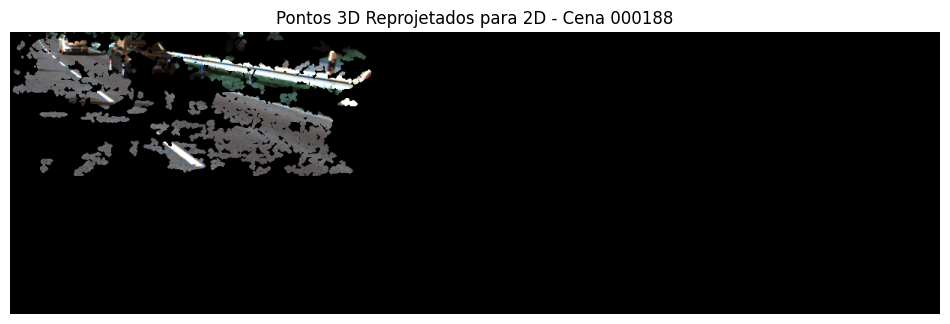

In [25]:
for result in results:
    scene_id = result['scene_id']
    
    reflected_points = result['out_points'].copy()
    reflected_points[:, 0] *= -1
    
    cam_matrix = np.zeros((3, 3))
    cam_matrix[0, 0] = result['Q'][2, 3]
    cam_matrix[1, 1] = result['Q'][2, 3]
    cam_matrix[0, 2] = -result['Q'][0, 3] / result['Q'][2, 3]
    cam_matrix[1, 2] = -result['Q'][1, 3] / result['Q'][2, 3]
    cam_matrix[2, 2] = 1.0
    
    projected_points, _ = cv.projectPoints(
        reflected_points, 
        np.zeros(3), np.zeros(3), 
        cam_matrix, 
        np.zeros(5)
    )
    projected_points = projected_points.reshape(-1, 2)
    
    blank_img = np.zeros_like(result['left_img'])
    
    for i, pt in enumerate(projected_points):
        pt_x = int(round(pt[0]))
        pt_y = int(round(pt[1]))
        if 0 <= pt_x < blank_img.shape[1] and 0 <= pt_y < blank_img.shape[0]:
            col = tuple(int(c) for c in result['out_colors'][i])
            cv.circle(blank_img, (pt_x, pt_y), 1, col, -1)
    
    plt.figure(figsize=(12, 8))
    plt.imshow(cv.cvtColor(blank_img, cv.COLOR_BGR2RGB))
    plt.title(f"Pontos 3D Reprojetados para 2D - Cena {scene_id}")
    plt.axis('off')
    plt.show()

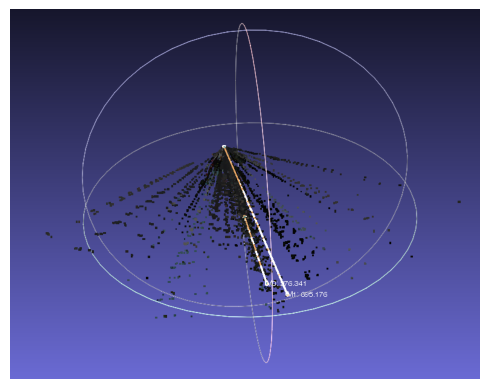

In [ ]:
base_url = "https://raw.githubusercontent.com/Delevati/vc-2024-2/main/img/task04/q2"
img_path1 = f"{base_url}/result_meshlab/meshlab-depth.png"
img_path2 = f"{base_url}/result_meshlab/meshlab-depth1.png"

img1 = cv.imread(img_path1)
img2 = cv.imread(img_path2)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(img1, cv.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Meshlab Depth 1")

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(img2, cv.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Meshlab Depth 2")

plt.tight_layout()
plt.show()